# Advanced Analytics & Risk Metrics

## Historical Value at Risk (VaR) and Conditional Value at Risk (CVaR)

Objective:
Calculate the 95% Historical VaR and CVaR for all mutual fund schemes using daily returns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
import sys
print(sys.executable)

d:\Bluestock-Mutual-Fund\venv\Scripts\python.exe


In [3]:
# Load datasets

nav = pd.read_csv("../data/processed/clean_nav_history.csv")

performance = pd.read_csv("../data/processed/clean_scheme_performance.csv")

transactions = pd.read_csv("../data/processed/clean_investor_transactions.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("Datasets Loaded Successfully!")

print("NAV:", nav.shape)
print("Performance:", performance.shape)
print("Transactions:", transactions.shape)
print("Portfolio:", portfolio.shape)

Datasets Loaded Successfully!
NAV: (46000, 3)
Performance: (40, 19)
Transactions: (32778, 13)
Portfolio: (322, 8)


In [4]:
# Display first few rows
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')


In [6]:
# Convert date to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort data
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily returns for each fund
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

# Display first few rows
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [7]:
print(nav.columns)

nav.head()

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='object')


,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [8]:
# Calculate Historical VaR and CVaR

var_cvar = []

for amfi, group in nav.groupby("amfi_code"):

    # Remove missing returns
    returns = group["daily_return"].dropna()

    # Skip funds with very few observations
    if len(returns) < 10:
        continue

    # 95% Historical VaR (5th percentile)
    var_95 = np.percentile(returns, 5)

    # CVaR = Average of returns below VaR
    cvar_95 = returns[returns <= var_95].mean()

    var_cvar.append({
        "amfi_code": amfi,
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })

# Convert to DataFrame
var_cvar = pd.DataFrame(var_cvar)

# Display first few rows
var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [9]:
print("Number of Funds:", len(var_cvar))

Number of Funds: 40


In [10]:
# Save the report
var_cvar.to_csv("../reports/var_cvar_report.csv", index=False)

print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!


## Rolling 90-Day Sharpe Ratio

**Objective:**

Calculate the rolling 90-day Sharpe Ratio for selected mutual funds and visualize their performance over time.

In [11]:
# Annual Risk-Free Rate (6.5%)
risk_free = 0.065

# Convert annual rate to daily rate
daily_rf = risk_free / 252

print("Daily Risk-Free Rate:", daily_rf)

Daily Risk-Free Rate: 0.00025793650793650796


In [12]:
# Calculate Rolling 90-Day Sharpe Ratio

rolling_data = []

for amfi, group in nav.groupby("amfi_code"):

    # Sort by date
    group = group.sort_values("date")

    # Daily returns
    returns = group["daily_return"]

    # 90-day rolling average return
    rolling_mean = returns.rolling(window=90).mean()

    # 90-day rolling standard deviation
    rolling_std = returns.rolling(window=90).std()

    # Rolling Sharpe Ratio
    rolling_sharpe = ((rolling_mean - daily_rf) / rolling_std) * np.sqrt(252)

    temp = pd.DataFrame({
        "date": group["date"],
        "amfi_code": amfi,
        "rolling_sharpe": rolling_sharpe
    })

    rolling_data.append(temp)

# Combine all funds
rolling_sharpe_df = pd.concat(rolling_data)

print("Rolling Sharpe calculated successfully!")
rolling_sharpe_df.head()

Rolling Sharpe calculated successfully!


,date,amfi_code,rolling_sharpe
0,2022-01-03,100016,NaN
1,2022-01-04,100016,NaN
2,2022-01-05,100016,NaN
3,2022-01-06,100016,NaN
4,2022-01-07,100016,NaN


In [13]:
# Select first 5 funds
top5_funds = rolling_sharpe_df["amfi_code"].unique()[:5]

print("Selected Funds:")
print(top5_funds)

Selected Funds:
[100016 100025 100033 101206 101207]


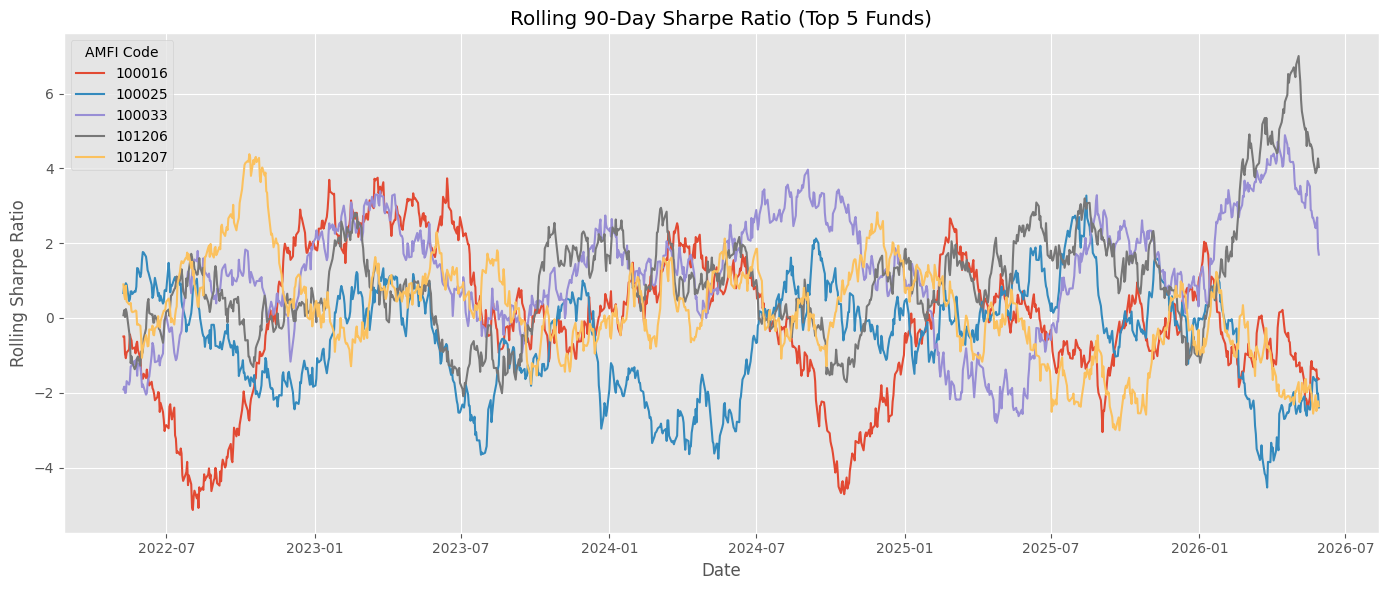

In [14]:
plt.figure(figsize=(14, 6))

for fund in top5_funds:
    fund_data = rolling_sharpe_df[
        rolling_sharpe_df["amfi_code"] == fund
    ]

    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe"],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio (Top 5 Funds)")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend(title="AMFI Code")
plt.grid(True)

plt.tight_layout()

plt.show()

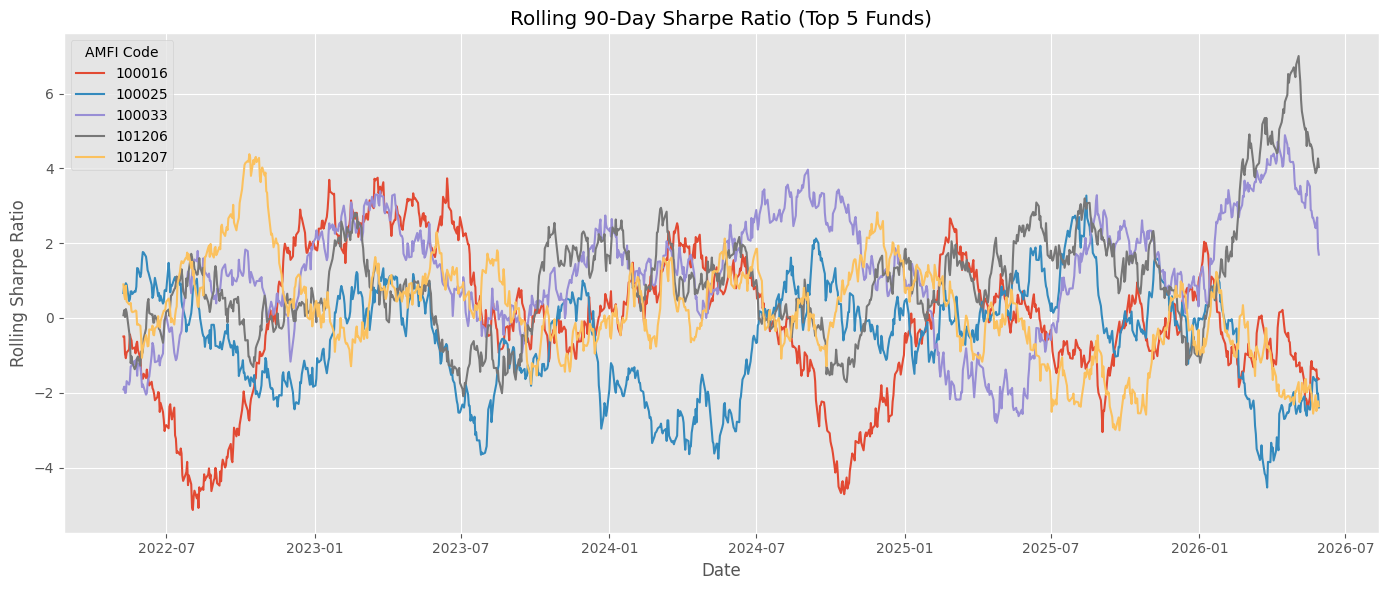

rolling_sharpe_chart.png saved successfully!


In [15]:
plt.figure(figsize=(14, 6))

for fund in top5_funds:
    fund_data = rolling_sharpe_df[
        rolling_sharpe_df["amfi_code"] == fund
    ]

    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe"],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio (Top 5 Funds)")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend(title="AMFI Code")
plt.grid(True)

plt.tight_layout()

plt.savefig("../reports/rolling_sharpe_chart.png", dpi=300)

plt.show()

print("rolling_sharpe_chart.png saved successfully!")

## Investor Cohort Analysis

**Objective:**

Analyze investor behavior by grouping investors based on their first transaction year. Compute the average SIP amount, total amount invested, and the most preferred mutual fund for each cohort.

In [16]:
# Display first few rows
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [17]:
print(transactions.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


In [20]:
# Convert transaction date to datetime
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

# Find each investor's first transaction date
first_transaction = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

# Rename the column
first_transaction.rename(
    columns={"transaction_date": "first_transaction_date"},
    inplace=True
)

# Extract the first transaction year
first_transaction["cohort_year"] = first_transaction["first_transaction_date"].dt.year

# Display the result
first_transaction.head()

,investor_id,first_transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [21]:
# Merge cohort year into transactions
transactions = transactions.merge(
    first_transaction[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

# Check the result
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [22]:
# Keep only SIP transactions
sip_transactions = transactions[
    transactions["transaction_type"] == "Sip"
]

# Cohort summary
cohort_summary = (
    sip_transactions
    .groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum")
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested
0,2024,10996.885825,214978121
1,2025,13505.209581,2255370


In [23]:
# Most preferred fund (AMFI code) for each cohort
top_fund = (
    sip_transactions
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="count")
)

top_fund = (
    top_fund
    .sort_values(["cohort_year", "count"], ascending=[True, False])
    .drop_duplicates("cohort_year")
)

top_fund

,cohort_year,amfi_code,count
24,2024,120504,536
62,2025,119599,8


In [24]:
# Combine cohort summary with top fund
cohort_analysis = cohort_summary.merge(
    top_fund[["cohort_year", "amfi_code"]],
    on="cohort_year",
    how="left"
)

cohort_analysis

,cohort_year,avg_sip_amount,total_invested,amfi_code
0,2024,10996.885825,214978121,120504
1,2025,13505.209581,2255370,119599


## SIP Continuity Analysis

**Objective:**

Analyze SIP continuity by calculating the average gap between consecutive SIP transactions for investors with at least 6 SIP transactions. Investors with an average gap greater than 35 days are flagged as **At Risk**.

In [25]:
# Keep only SIP transactions
sip_data = transactions[
    transactions["transaction_type"] == "Sip"
].copy()

# Sort by investor and date
sip_data = sip_data.sort_values(
    ["investor_id", "transaction_date"]
)

sip_data.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
16803,INV000002,2024-09-21,120841,Sip,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
31881,INV000002,2025-05-17,119094,Sip,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024


In [26]:
# Calculate gap in days
sip_data["gap_days"] = (
    sip_data
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_data.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,Sip,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,Sip,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0
12652,INV000003,2024-07-16,101207,Sip,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,NaN
27622,INV000003,2025-03-11,149322,Sip,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,238.0
4773,INV000004,2024-03-16,101208,Sip,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,Sip,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,Sip,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0


In [27]:
# Count SIP transactions
sip_counts = (
    sip_data
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

# Keep only investors with at least 6 SIPs
eligible_investors = sip_counts[
    sip_counts["sip_count"] >= 6
]

eligible_investors.head()

,investor_id,sip_count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


In [28]:
# Keep only eligible investors
eligible_sip = sip_data.merge(
    eligible_investors[["investor_id"]],
    on="investor_id",
    how="inner"
)

# Average gap
avg_gap = (
    eligible_sip
    .groupby("investor_id")
    .agg(
        avg_gap_days=("gap_days", "mean")
    )
    .reset_index()
)

avg_gap.head()

,investor_id,avg_gap_days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000


In [29]:
# Flag investors
avg_gap["status"] = np.where(
    avg_gap["avg_gap_days"] > 35,
    "At Risk",
    "Healthy"
)

avg_gap.head(10)

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk
5,INV000013,55.333333,At Risk
6,INV000014,75.333333,At Risk
7,INV000023,58.571429,At Risk
8,INV000028,93.600000,At Risk
9,INV000029,60.666667,At Risk


In [30]:
print("Total Eligible Investors:", len(avg_gap))

print("\nStatus Distribution:")
print(avg_gap["status"].value_counts())

Total Eligible Investors: 1362

Status Distribution:
status
At Risk    1332
Healthy      30
Name: count, dtype: int64


In [31]:
print(performance.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')


In [32]:
print("Available Risk Grades:")
print(performance["risk_grade"].unique())

Available Risk Grades:
['Moderate' 'Very High' 'Low' 'High' 'Moderately High']
